In [ ]:
#Trends of Data Analyst Job Skills in the Philippines through out the year
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
#load the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#clean the data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [54]:
#get the data to work with
df_DA_PH = df[(df['job_country'] == 'Philippines') & (df['job_title_short'] == 'Data Analyst')].copy()
df_DA_PH = df_DA_PH.explode('job_skills')
df_DA_PH['job_posted_month'] = pd.to_datetime(df_DA_PH['job_posted_date']).dt.month


In [ ]:
#set up the table for visualization
df_pivot = df_DA_PH.pivot_table(index='job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)
df_pivot.loc['total'] = df_pivot.sum()
df_pivot = df_pivot.sort_values(by='total', axis=1, ascending=False)
df_pivot.drop('total', axis=0, inplace=True)
df_pivot = df_pivot.reset_index()
#df_pivot['job_posted_month'] = pd.to_datetime(df_pivot['job_posted_month'], format='%m').dt.strftime(date_format='%b') ---> this should go after getting the next table
df_pivot.set_index('job_posted_month', inplace=True)
df_pivot

job_skills,excel,sql,python,tableau,power bi,sas,r,powerpoint,word,sheets,...,graphql,node.js,centos,chef,unity,kubernetes,trello,theano,elasticsearch,neo4j
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,323,234,144,121,113,62,72,78,75,37,...,0,0,0,1,0,0,0,0,1,0
2,172,141,100,71,61,32,41,44,38,15,...,0,0,0,0,0,0,0,0,0,0
3,143,141,65,74,60,46,34,34,35,23,...,0,0,1,0,0,0,0,0,0,0
4,179,105,59,71,59,32,31,36,33,27,...,0,0,0,0,0,0,0,0,0,0
5,135,132,82,64,65,26,38,29,25,21,...,0,0,0,0,0,0,0,0,0,0
6,186,138,67,74,81,42,26,31,33,32,...,0,0,0,0,1,0,0,1,0,0
7,192,189,98,102,103,64,63,36,41,14,...,0,0,0,0,0,0,1,0,0,0
8,209,186,84,100,101,60,50,53,42,22,...,1,1,0,0,0,0,0,0,0,0
9,186,133,70,78,82,44,34,40,35,17,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='job_posted_month'>

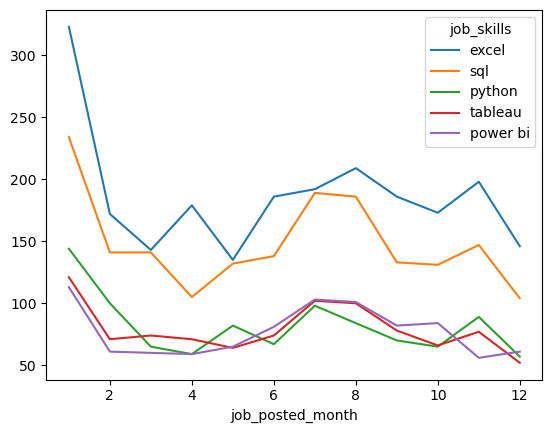

In [212]:
#visualize the initial table
sns.lineplot(data=df_pivot.iloc[:,:5], dashes=False)

In [ ]:
#create another table to join in the main table.
#the goal of this table is to achieve the % of job_skills instead of using counts

df_total = df_DA_PH['job_posted_month'].value_counts()
df_percent = df_pivot.div(df_total/100, axis=0)

job_skills,job_posted_month,excel,sql,python,tableau,power bi,sas,r,powerpoint,word,...,graphql,node.js,centos,chef,unity,kubernetes,trello,theano,elasticsearch,neo4j
0,1,14.516854,10.516854,6.471910,5.438202,5.078652,2.786517,3.235955,3.505618,3.370787,...,0.000000,0.000000,0.000000,0.044944,0.000000,0.000000,0.000000,0.000000,0.044944,0.00000
1,2,14.017930,11.491443,8.149959,5.786471,4.971475,2.607987,3.341483,3.585982,3.096985,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
2,3,13.554502,13.364929,6.161137,7.014218,5.687204,4.360190,3.222749,3.222749,3.317536,...,0.000000,0.000000,0.094787,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
3,4,18.626431,10.926119,6.139438,7.388137,6.139438,3.329865,3.225806,3.746098,3.433923,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
4,5,13.094083,12.803104,7.953443,6.207565,6.304559,2.521823,3.685742,2.812803,2.424830,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
5,6,15.843271,11.754685,5.706985,6.303237,6.899489,3.577513,2.214651,2.640545,2.810903,...,0.000000,0.000000,0.000000,0.000000,0.085179,0.000000,0.000000,0.085179,0.000000,0.00000
6,7,12.565445,12.369110,6.413613,6.675393,6.740838,4.188482,4.123037,2.356021,2.683246,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.065445,0.000000,0.000000,0.00000
7,8,14.635854,13.025210,5.882353,7.002801,7.072829,4.201681,3.501401,3.711485,2.941176,...,0.070028,0.070028,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
8,9,15.604027,11.157718,5.872483,6.543624,6.879195,3.691275,2.852349,3.355705,2.936242,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
9,10,14.978355,11.341991,5.627706,5.714286,7.272727,3.116883,3.030303,2.857143,2.770563,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.08658


In [245]:
#visualze the latest table
df_percent = df_percent.reset_index()
df_percent['job_posted_month'] = pd.to_datetime(df_percent['job_posted_month'], format='%m').dt.strftime(date_format='%b')
df_percent.set_index('job_posted_month', inplace=True)


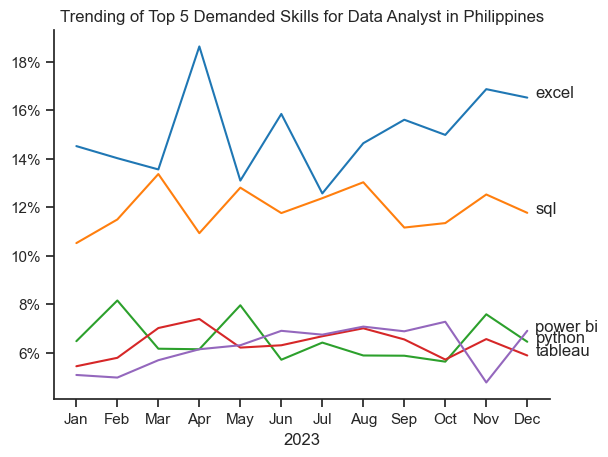

In [ ]:
from matplotlib.ticker import PercentFormatter
sns.lineplot(data=df_percent.iloc[:,:5], dashes=False, legend=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.title('Trending of Top 5 Demanded Skills for Data Analyst in Philippines')
plt.xlabel('2023')
for i in range(5):
    plt.text(11.2,df_percent.iloc[-1,i],df_percent.columns[i])